# Post-competition research: three-state HMM

This notebook tests whether a Hidden Markov Model (HMM) can identify **negative**, **neutral**, and **upward** price-drift regimes. It fits only on `p1`–`p40` from the training instruments, forecasts the ten unobserved steps to `p50`, evaluates against the training `p50`, and creates a competition-format submission for the test instruments.

## Modelling choices

- One shared three-state Gaussian HMM is fitted to all training sequences. Each instrument still gets its own filtered state probabilities at `p40`; separate 39-observation models would be poorly identified.
- Emissions are additive one-step price changes, `p(t) - p(t-1)`. This is preferable to log returns here because zero is a valid observed price.
- `p50` is never used to fit the HMM. It is a genuine validation target.
- The forecast is the expected sum of ten future state-dependent changes, clipped at zero.
- A sell is attractive when predicted gain `p40 - predicted_p50` is positive. We take at most the 4,000 largest predicted gains.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
RANDOM_STATE = 42
MAX_SELLS = 4_000
HORIZON = 10

In [2]:
def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "train.csv").exists() and (candidate / "test.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find train.csv and test.csv above the current directory.")


REPO_ROOT = find_repo_root()
train = pd.read_csv(REPO_ROOT / "train.csv")
test = pd.read_csv(REPO_ROOT / "test.csv")
sample_submission = pd.read_csv(REPO_ROOT / "sample_submission.csv")
price_columns = [f"p{i}" for i in range(1, 41)]

assert train.columns.tolist() == ["ID", *price_columns, "p50"]
assert test.columns.tolist() == ["ID", *price_columns]
assert not train.isna().any().any() and not test.isna().any().any()

print(f"Repository: {REPO_ROOT}")
print(f"train: {train.shape}; test: {test.shape}; sample submission: {sample_submission.shape}")
train.head()

Repository: /Users/alexkara/repos/dscubedkaggle2026/DScubedKaggle2026
train: (10000, 42); test: (10000, 41); sample submission: (10000, 2)


,ID,p1,p2,p3,p4,p5,p6,p7,p8,p9,...,p32,p33,p34,p35,p36,p37,p38,p39,p40,p50
0,0,95.4400,98.6300,102.7900,99.7100,96.4800,93.3200,88.9900,84.6100,83.3900,...,90.5700,86.8800,86.2700,83.4200,80.2500,76.9500,73.6900,69.1500,67.0700,56.6200
1,1,104.1100,104.3500,104.3200,104.5500,103.2800,99.0400,96.3700,97.0700,96.4800,...,65.9400,70.9000,70.0700,69.4300,69.4500,68.2400,68.3900,72.0000,71.6700,52.6000
2,2,109.6400,109.5800,110.9200,108.5300,104.9800,102.6400,107.2100,107.9600,114.2800,...,117.4900,117.1900,120.9300,122.8400,124.5800,126.5000,130.1700,131.7700,136.2200,125.9400
3,3,104.9900,103.4800,104.3500,104.6400,104.9000,101.7300,100.8900,104.8900,105.0200,...,106.0800,108.0900,108.1400,109.1000,108.6800,111.6000,115.2300,117.0500,119.0200,138.9700
4,4,108.9900,102.7800,99.9900,98.1700,94.4100,95.7500,96.3500,98.1000,98.8500,...,100.8500,97.5900,96.2300,94.3100,97.4200,100.8500,104.6100,108.9100,111.3100,120.8900


,value
training instruments,"10,000.0000"
observed prices per instrument,40.0000
one-step changes used for fitting,"390,000.0000"
mean one-step change,-0.0119
std one-step change,2.9158
zero prices in train p1-p40,13.0000


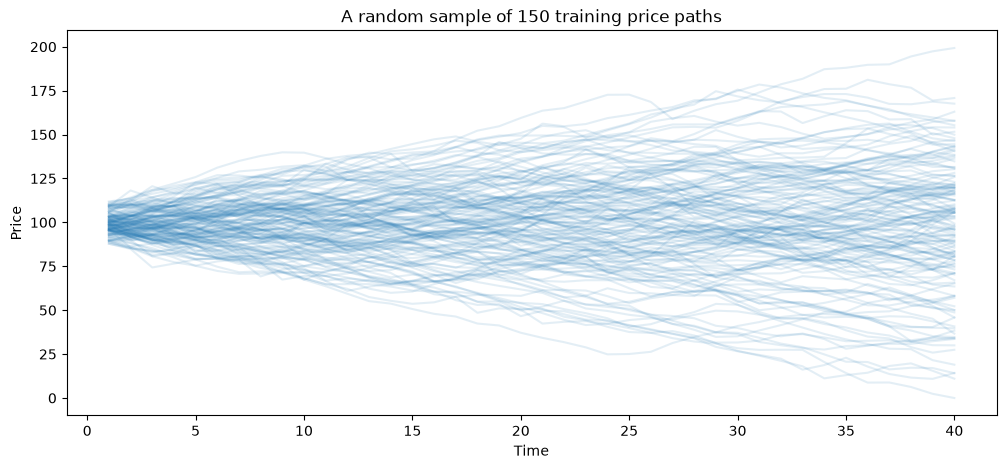

In [3]:
train_prices = train[price_columns].to_numpy(dtype=float)
test_prices = test[price_columns].to_numpy(dtype=float)
train_changes = np.diff(train_prices, axis=1)

overview = pd.Series({
    "training instruments": len(train),
    "observed prices per instrument": train_prices.shape[1],
    "one-step changes used for fitting": train_changes.size,
    "mean one-step change": train_changes.mean(),
    "std one-step change": train_changes.std(),
    "zero prices in train p1-p40": (train_prices == 0).sum(),
})
display(overview.to_frame("value"))

rng = np.random.default_rng(RANDOM_STATE)
sample_rows = rng.choice(len(train), size=150, replace=False)
plt.figure(figsize=(12, 5))
plt.plot(np.arange(1, 41), train_prices[sample_rows].T, alpha=0.12, color="tab:blue")
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("A random sample of 150 training price paths")
plt.show()

## Gaussian HMM implementation

The implementation below uses scaled forward-backward recursions and Baum-Welch expectation-maximisation. It has no dependency on `hmmlearn`, which keeps the notebook reproducible in the repository environment. State labels are made identifiable by sorting their fitted mean changes after every update.

In [4]:
class GaussianDriftHMM:
    """A small vectorised Gaussian HMM for equal-length scalar sequences."""

    def __init__(self, n_states=3, max_iter=100, tol=1e-6, min_std=1e-3):
        self.n_states = n_states
        self.max_iter = max_iter
        self.tol = tol
        self.min_std = min_std

    def _check_X(self, X):
        X = np.asarray(X, dtype=float)
        if X.ndim != 2 or X.shape[1] < 2:
            raise ValueError("X must be a 2D array with at least two observations per sequence.")
        if not np.isfinite(X).all():
            raise ValueError("X contains non-finite values.")
        return X

    def _emission_probabilities(self, X):
        z = (X[:, :, None] - self.means_) / self.stds_
        density = np.exp(-0.5 * z**2) / (self.stds_ * np.sqrt(2 * np.pi))
        return np.maximum(density, np.finfo(float).tiny)

    def _forward(self, X):
        emissions = self._emission_probabilities(X)
        n_sequences, n_steps = X.shape
        alpha = np.empty((n_sequences, n_steps, self.n_states))
        scales = np.empty((n_sequences, n_steps))

        alpha[:, 0] = self.startprob_ * emissions[:, 0]
        scales[:, 0] = alpha[:, 0].sum(axis=1)
        alpha[:, 0] /= scales[:, 0, None]

        for t in range(1, n_steps):
            alpha[:, t] = (alpha[:, t - 1] @ self.transmat_) * emissions[:, t]
            scales[:, t] = alpha[:, t].sum(axis=1)
            alpha[:, t] /= scales[:, t, None]

        log_likelihood = np.log(scales).sum()
        return alpha, emissions, scales, log_likelihood

    def fit(self, X):
        X = self._check_X(X)
        k = self.n_states
        self.means_ = np.quantile(X, np.linspace(0.15, 0.85, k))
        self.stds_ = np.full(k, X.std())
        self.startprob_ = np.full(k, 1 / k)
        self.transmat_ = np.full((k, k), 0.05 / (k - 1))
        np.fill_diagonal(self.transmat_, 0.95)
        self.log_likelihood_history_ = []

        for _ in range(self.max_iter):
            alpha, emissions, scales, log_likelihood = self._forward(X)
            n_sequences, n_steps, _ = alpha.shape

            beta = np.ones_like(alpha)
            for t in range(n_steps - 2, -1, -1):
                beta[:, t] = (beta[:, t + 1] * emissions[:, t + 1]) @ self.transmat_.T
                beta[:, t] /= scales[:, t + 1, None]

            gamma = alpha * beta
            gamma /= gamma.sum(axis=2, keepdims=True)

            transition_counts = np.zeros((k, k))
            for t in range(n_steps - 1):
                xi = (
                    alpha[:, t, :, None]
                    * self.transmat_[None, :, :]
                    * (emissions[:, t + 1] * beta[:, t + 1])[:, None, :]
                )
                xi /= xi.sum(axis=(1, 2), keepdims=True)
                transition_counts += xi.sum(axis=0)

            state_weights = gamma.sum(axis=(0, 1))
            self.startprob_ = gamma[:, 0].mean(axis=0)
            self.transmat_ = transition_counts / transition_counts.sum(axis=1, keepdims=True)
            self.means_ = (gamma * X[:, :, None]).sum(axis=(0, 1)) / state_weights
            variances = (
                gamma * (X[:, :, None] - self.means_) ** 2
            ).sum(axis=(0, 1)) / state_weights
            self.stds_ = np.sqrt(np.maximum(variances, self.min_std**2))

            order = np.argsort(self.means_)
            self.means_ = self.means_[order]
            self.stds_ = self.stds_[order]
            self.startprob_ = self.startprob_[order]
            self.transmat_ = self.transmat_[np.ix_(order, order)]
            self.log_likelihood_history_.append(log_likelihood)

            if len(self.log_likelihood_history_) > 1:
                previous = self.log_likelihood_history_[-2]
                if abs(log_likelihood - previous) <= self.tol * (1 + abs(previous)):
                    break
        return self

    def filtered_state_probabilities(self, X):
        X = self._check_X(X)
        alpha, _, _, _ = self._forward(X)
        return alpha[:, -1]

    def predict_price(self, prices, horizon=10):
        prices = np.asarray(prices, dtype=float)
        state_probability = self.filtered_state_probabilities(np.diff(prices, axis=1))
        expected_change = np.zeros(len(prices))
        for _ in range(horizon):
            state_probability = state_probability @ self.transmat_
            expected_change += state_probability @ self.means_
        return np.maximum(0, prices[:, -1] + expected_change)

In [5]:
hmm = GaussianDriftHMM(n_states=3, max_iter=100, tol=1e-6)
hmm.fit(train_changes)

state_names = ["negative drift", "neutral drift", "upward drift"]
state_summary = pd.DataFrame({
    "state": state_names,
    "mean one-step change": hmm.means_,
    "emission std": hmm.stds_,
    "starting probability": hmm.startprob_,
    "expected duration": 1 / (1 - np.diag(hmm.transmat_)),
}).set_index("state")

print(f"Converged after {len(hmm.log_likelihood_history_)} EM iterations")
display(state_summary)
display(pd.DataFrame(hmm.transmat_, index=state_names, columns=state_names).rename_axis("from / to"))

Converged after 82 EM iterations


,mean one-step change,emission std,starting probability,expected duration
state,,,,
negative drift,-2.2573,1.5575,0.3683,4.8996
neutral drift,-0.1635,4.2176,0.1972,1.2556
upward drift,1.9795,1.5743,0.4345,5.1379


,negative drift,neutral drift,upward drift
from / to,,,
negative drift,0.7959,0.1256,0.0785
neutral drift,0.3924,0.2036,0.4040
upward drift,0.0537,0.1409,0.8054


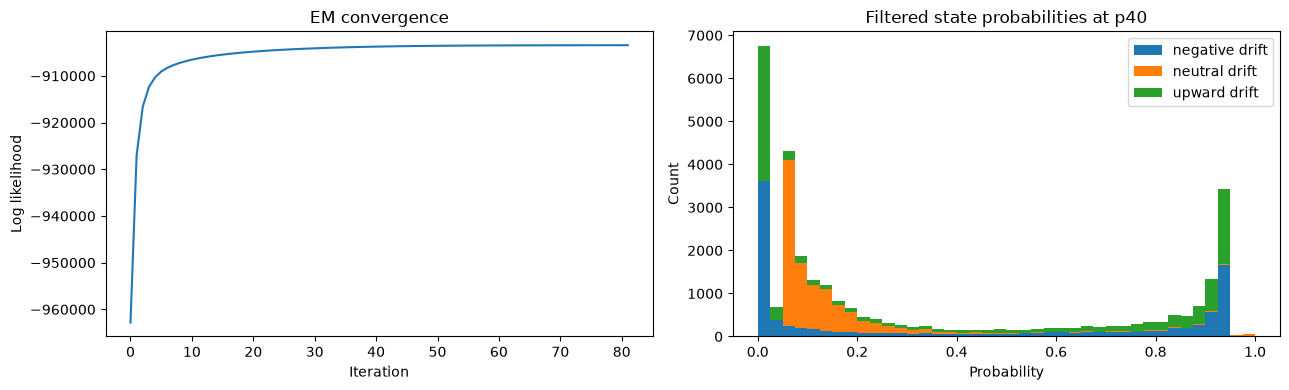

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hmm.log_likelihood_history_)
axes[0].set(title="EM convergence", xlabel="Iteration", ylabel="Log likelihood")

last_state_probability = hmm.filtered_state_probabilities(train_changes)
axes[1].hist(last_state_probability, bins=40, stacked=True, label=state_names)
axes[1].set(title="Filtered state probabilities at p40", xlabel="Probability", ylabel="Count")
axes[1].legend()
plt.tight_layout()
plt.show()

## Validation on training `p50`

Forecast accuracy is useful, but the competition reward is the decisive measure. The no-change and last-step-drift forecasts provide simple reference points. The oracle uses the known validation target to show the maximum possible training reward and is **not** a usable model.

In [7]:
def make_sell_decisions(predicted_p50, p40, max_sells=MAX_SELLS):
    predicted_gain = np.asarray(p40) - np.asarray(predicted_p50)
    eligible = np.flatnonzero(predicted_gain > 0)
    ranked = eligible[np.argsort(predicted_gain[eligible])[::-1]]
    chosen = ranked[:max_sells]
    sell = np.zeros(len(predicted_gain), dtype=np.int8)
    sell[chosen] = 1
    return sell, predicted_gain


def realised_reward(sell, p40, p50):
    return np.sum(np.asarray(sell) * (np.asarray(p40) - np.asarray(p50)))


def evaluate_forecast(name, prediction, p40, target):
    sell, _ = make_sell_decisions(prediction, p40)
    return {
        "forecast": name,
        "MAE": np.mean(np.abs(prediction - target)),
        "RMSE": np.sqrt(np.mean((prediction - target) ** 2)),
        "change correlation": np.corrcoef(prediction - p40, target - p40)[0, 1]
            if np.std(prediction - p40) > 0 else np.nan,
        "number sold": sell.sum(),
        "validation R": realised_reward(sell, p40, target),
    }


p40_train = train_prices[:, -1]
p50_train = train["p50"].to_numpy(dtype=float)
hmm_train_prediction = hmm.predict_price(train_prices, horizon=HORIZON)
last_step_prediction = np.maximum(0, p40_train + HORIZON * train_changes[:, -1])
no_change_prediction = p40_train.copy()

validation_results = pd.DataFrame([
    evaluate_forecast("No change (p40)", no_change_prediction, p40_train, p50_train),
    evaluate_forecast("Last-step drift", last_step_prediction, p40_train, p50_train),
    evaluate_forecast("Three-state HMM", hmm_train_prediction, p40_train, p50_train),
]).set_index("forecast")

oracle_sell, _ = make_sell_decisions(p50_train, p40_train)
oracle_reward = realised_reward(oracle_sell, p40_train, p50_train)
display(validation_results)
print(f"Oracle validation R (not attainable): {oracle_reward:,.2f}")

,MAE,RMSE,change correlation,number sold,validation R
forecast,,,,,
No change (p40),12.5393,15.1763,NaN,0,0.0000
Last-step drift,23.2048,29.7026,0.2155,4000,"17,481.9900"
Three-state HMM,12.0171,14.5598,0.2824,4000,"19,120.6400"


Oracle validation R (not attainable): 60,261.46


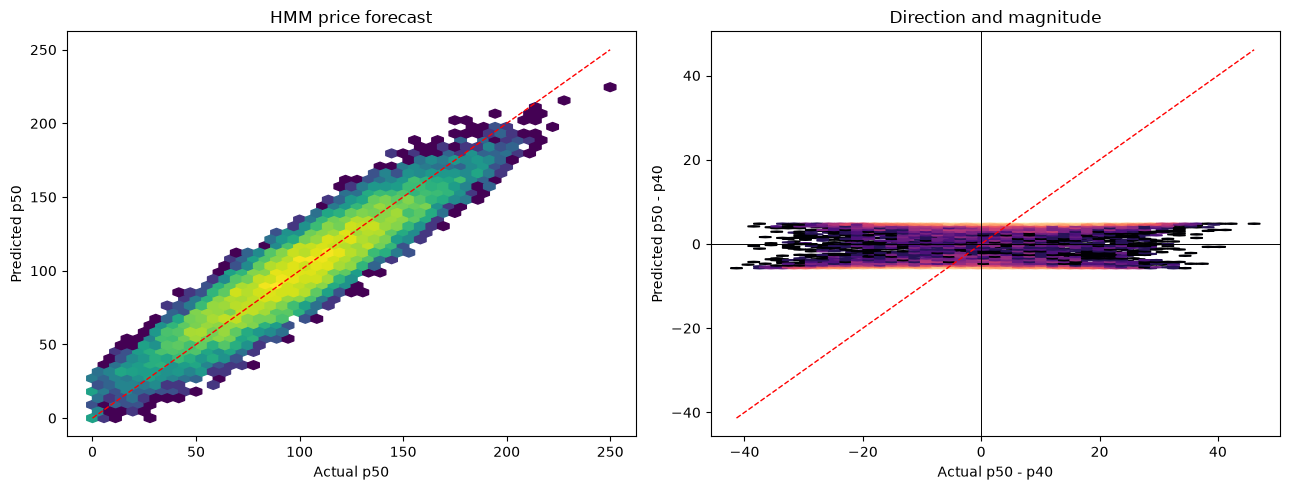

In [8]:
actual_change = p50_train - p40_train
predicted_change = hmm_train_prediction - p40_train

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
limits = [min(p50_train.min(), hmm_train_prediction.min()), max(p50_train.max(), hmm_train_prediction.max())]
axes[0].hexbin(p50_train, hmm_train_prediction, gridsize=45, mincnt=1, bins="log", cmap="viridis")
axes[0].plot(limits, limits, "r--", linewidth=1)
axes[0].set(xlabel="Actual p50", ylabel="Predicted p50", title="HMM price forecast")

change_limits = [min(actual_change.min(), predicted_change.min()), max(actual_change.max(), predicted_change.max())]
axes[1].hexbin(actual_change, predicted_change, gridsize=45, mincnt=1, bins="log", cmap="magma")
axes[1].plot(change_limits, change_limits, "r--", linewidth=1)
axes[1].axhline(0, color="black", linewidth=0.7)
axes[1].axvline(0, color="black", linewidth=0.7)
axes[1].set(xlabel="Actual p50 - p40", ylabel="Predicted p50 - p40", title="Direction and magnitude")
plt.tight_layout()
plt.show()

## Fit-to-test forecast and submission

The fitted HMM has used all available training paths but no `p50` values. We now infer the state distribution for each test instrument, forecast its `p50`, rank expected selling gains, and write the exact `ID,sell` format.

In [9]:
hmm_test_prediction = hmm.predict_price(test_prices, horizon=HORIZON)
test_sell, test_expected_gain = make_sell_decisions(hmm_test_prediction, test_prices[:, -1])

submission = test[["ID"]].copy()
submission["sell"] = test_sell

assert submission.columns.tolist() == ["ID", "sell"]
assert submission["ID"].equals(sample_submission["ID"])
assert set(submission["sell"].unique()).issubset({0, 1})
assert submission["sell"].sum() <= MAX_SELLS

submission_path = REPO_ROOT / "post-comp research" / "hmm_submission.csv"
submission.to_csv(submission_path, index=False)

test_forecasts = pd.DataFrame({
    "ID": test["ID"],
    "p40": test_prices[:, -1],
    "predicted_p50": hmm_test_prediction,
    "predicted_gain_if_sold": test_expected_gain,
    "sell": test_sell,
}).sort_values("predicted_gain_if_sold", ascending=False)

print(f"Wrote {submission_path}")
print(f"Sell decisions: {submission['sell'].sum():,} / {len(submission):,}")
display(test_forecasts.head(10))
display(submission.head())

Wrote /Users/alexkara/repos/dscubedkaggle2026/DScubedKaggle2026/post-comp research/hmm_submission.csv
Sell decisions: 4,000 / 10,000


,ID,p40,predicted_p50,predicted_gain_if_sold,sell
2646,2646,110.7100,104.9579,5.7521,1
87,87,116.6400,110.8880,5.7520,1
4091,4091,75.5000,69.7480,5.7520,1
3668,3668,56.6000,50.8481,5.7519,1
1374,1374,119.6200,113.8682,5.7518,1
5957,5957,49.9800,44.2282,5.7518,1
1712,1712,61.9100,56.1583,5.7517,1
5483,5483,34.5300,28.7783,5.7517,1
9346,9346,124.8500,119.0984,5.7516,1
6907,6907,132.2600,126.5084,5.7516,1


,ID,sell
0,0,1
1,1,0
2,2,0
3,3,0
4,4,0


## Interpretation

The most relevant comparison is `validation R`, not price error alone: the submission only needs to rank instruments whose prices are most likely to fall. Compare the HMM with the last-step baseline and its reward as a fraction of the oracle reward. If the HMM wins, persistence in the fitted drift states contains useful information beyond the latest price move.

A useful next experiment would be an honest row-level cross-validation loop for modelling choices (number of states, state covariance constraints, or blending with a recent-trend model), while keeping each fold's `p50` completely outside HMM fitting.